# Build your own performance (the airframe envelope)

Every aircraft in OpenCDaRR carries a `Performance` — the horizontal flight envelope of *that* airframe: how fast it may go, how hard it may accelerate, and how tightly it may turn. It is deliberately **plain data**: one frozen instance per airframe, kept separate from the kinematics that reads it. A new airframe is therefore a *value* you write, not code you fork.

This notebook builds two of your own — a heavy-lift **multirotor** and a large, fast **fixed-wing** — shows how the envelope is wired in, and makes the limits *visible* by flying each through a hard manoeuvre.

In [1]:
# Install once (from the repo root, in a terminal):  pip install -e ".[examples]"
# %pip install -e "..[examples]"

## 1. Performance is plain data

A `Performance` is a frozen dataclass of six numbers. The two built-ins are a DJI Matrice 600 multirotor (`M600`) and a small fixed-wing UAV (`SMALL_FIXEDWING`). Notice which fields each one actually *uses*: the multirotor sets a yaw-rate limit and leaves the bank fields at `0`; the fixed-wing sets bank limits and a positive stall speed (`v_min`). Those zeros mean "not applicable", not a real limit — a distinction section 2 leans on.

In [2]:
%matplotlib inline
from dataclasses import fields
from opencdarr.performance import Performance, M600, SMALL_FIXEDWING

print(f"{'field':14}{'M600':>10}{'SMALL_FIXEDWING':>18}   (multirotor / fixed-wing)")
for f in fields(Performance):
    print(f"{f.name:14}{getattr(M600, f.name):10.1f}{getattr(SMALL_FIXEDWING, f.name):18.1f}")

field               M600   SMALL_FIXEDWING   (multirotor / fixed-wing)
v_max               18.0              25.0
v_min              -18.0              12.0
ax                   5.0               2.0
yaw_rate_max        90.0               0.0
phi_max              0.0              44.0
roll_rate_max        0.0              60.0


## 2. The envelope must match the airframe

The kinematics *reads* these fields, so an envelope built for one airframe cannot drive another. A fixed-wing turns by banking, so it needs `phi_max > 0`; hand it the M600's `phi_max = 0` and it could never turn — it would fly dead straight. Rather than do that silently, each kinematics rejects an envelope it cannot use, at the moment you build the `Agent`.

In [3]:
from opencdarr.kinematics import Multirotor, FixedWing
from opencdarr.fleet import Agent
from opencdarr.state import AircraftState

state = AircraftState(id="X", lat=52.0, lon=4.0, trk=0.0, gs=15.0, yaw=0.0)

for perf, kinematics, label in [
    (M600, FixedWing(), "M600 (a multirotor envelope) on a FixedWing"),
    (SMALL_FIXEDWING, Multirotor(), "SMALL_FIXEDWING (a fixed-wing envelope) on a Multirotor"),
]:
    try:
        Agent(state, perf, kinematics)
        print(f"{label}: constructed (no guard!)")
    except ValueError as e:
        print(f"{label}:\n  -> {e}\n")

M600 (a multirotor envelope) on a FixedWing:
  -> FixedWing was given an envelope it cannot fly: phi_max must be > 0 (a fixed-wing turns by banking); roll_rate_max must be > 0 (bank could never change); v_min is the stall speed and must be > 0. This looks like a multirotor envelope (e.g. M600); pass a fixed-wing Performance such as SMALL_FIXEDWING.

SMALL_FIXEDWING (a fixed-wing envelope) on a Multirotor:
  -> Multirotor was given an envelope built for a banking airframe (phi_max=44.0, roll_rate_max=60.0); a multirotor does not bank. This looks like a fixed-wing envelope (e.g. SMALL_FIXEDWING); pass a multirotor Performance such as M600.



## 3. Build your own multirotor: a heavy-lift drone and a racing quad

Two multirotors, two envelopes. The **cargo** drone is heavy — a low top speed and a gentle acceleration limit. The **racer** is light — fast, and it can slam its velocity around. Nothing else changes: same kinematics, same scenario, only six numbers.

In [4]:
CARGO = Performance(v_max=12.0, v_min=-12.0, ax=1.5,  yaw_rate_max=40.0)
RACER = Performance(v_max=25.0, v_min=-25.0, ax=12.0, yaw_rate_max=200.0)

A multirotor steers by changing its *velocity vector*, and `ax` caps how fast that vector may change. To see it, command each drone — cruising north — to switch to due east at the same speed, and plot the ground track. The cargo drone, ramp-limited, swings wide before it comes around; the racer snaps the corner. Same command, same speed; the envelope is the whole difference.

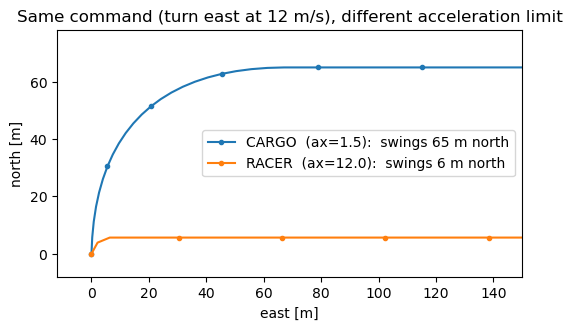

In [5]:
import math
import matplotlib.pyplot as plt
from opencdarr.kinematics import MotionCommand
from opencdarr import geo

def track_enu(states):
    # ground track of a state history as local east/north metres from the first point
    lat0, lon0 = states[0].lat, states[0].lon
    east, north = [], []
    for s in states:
        brg, d = geo.qdrdist(lat0, lon0, s.lat, s.lon)
        east.append(d * math.sin(math.radians(brg)))
        north.append(d * math.cos(math.radians(brg)))
    return east, north

def fly_slew(perf, speed, T=18.0, dt=0.5):
    # cruise north, then command a switch to due east; return the state history
    s = AircraftState(id="X", lat=52.0, lon=4.0, trk=0.0, gs=speed, yaw=0.0)
    cmd = MotionCommand(target_velocity=(speed, 0.0))
    hist = [s]
    for _ in range(int(T / dt)):
        s = Multirotor().step(s, cmd, perf, dt)
        hist.append(s)
    return hist

speed = 12.0
fig, ax = plt.subplots(figsize=(6, 4))
for perf, name in [(CARGO, "CARGO"), (RACER, "RACER")]:
    east, north = track_enu(fly_slew(perf, speed))
    ax.plot(east, north, marker=".", markevery=6,
            label=f"{name}  (ax={perf.ax}):  swings {max(north):.0f} m north")
ax.set_aspect("equal"); ax.set_xlim(-12, 150); ax.set_ylim(-8, 78)
ax.set_xlabel("east [m]"); ax.set_ylabel("north [m]")
ax.set_title("Same command (turn east at 12 m/s), different acceleration limit")
ax.legend()
plt.show()

The corner width *is* the envelope. The cargo drone's low `ax` costs it a wide arc — it keeps drifting north while it slowly builds an easterly velocity; the racer's high `ax` snaps almost square. Raising `v_max` would stretch both tracks out; raising `ax` tightens the corner.

## 4. Build your own fixed-wing: a big, fast aircraft

A fixed-wing does not sidestep — it *banks* to turn, and its turn radius is set by physics: `R = V² / (g·tan φ)`. That `V²` is unforgiving. Build a large aircraft that cruises at 80 m/s and banks a conservative 30°, next to the small UAV cruising at 17 m/s and banking 44°, and the big one needs a vastly wider circle to come around.

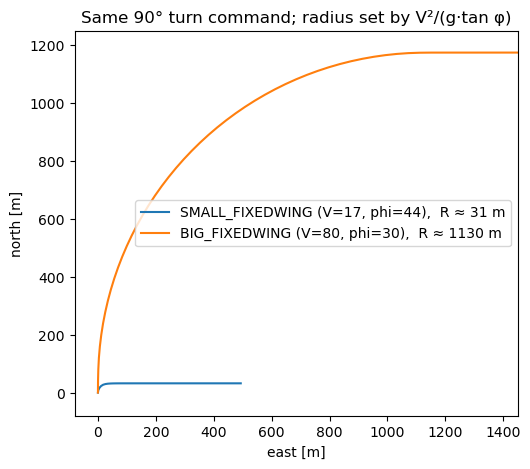

In [6]:
BIG_FIXEDWING = Performance(v_max=100.0, v_min=50.0, ax=2.0, phi_max=30.0, roll_rate_max=15.0)

def fly_turn(perf, cruise, T=30.0, dt=0.5):
    # fly north at cruise, then command a 90-degree easterly turn; return the history
    s = AircraftState(id="X", lat=52.0, lon=4.0, trk=0.0, gs=cruise, yaw=0.0, bank=0.0)
    cmd = MotionCommand(target_course=90.0, target_airspeed=cruise)
    hist = [s]
    for _ in range(int(T / dt)):
        s = FixedWing().step(s, cmd, perf, dt)
        hist.append(s)
    return hist

fig, ax = plt.subplots(figsize=(6, 5))
for perf, cruise, name in [
    (SMALL_FIXEDWING, 17.0, "SMALL_FIXEDWING (V=17, phi=44)"),
    (BIG_FIXEDWING,   80.0, "BIG_FIXEDWING (V=80, phi=30)"),
]:
    east, north = track_enu(fly_turn(perf, cruise))
    R = cruise ** 2 / (9.81 * math.tan(math.radians(perf.phi_max)))
    ax.plot(east, north, label=f"{name},  R ≈ {R:.0f} m")
ax.set_aspect("equal"); ax.set_xlim(-80, 1450); ax.set_ylim(-80, 1250)
ax.set_xlabel("east [m]"); ax.set_ylabel("north [m]")
ax.set_title("Same 90° turn command; radius set by V²/(g·tan φ)")
ax.legend()
plt.show()

The small UAV curls around inside ~30 m; the big aircraft sweeps a turn more than a kilometre wide. Neither "flies worse" — they simply live in different envelopes. A separation algorithm that ignored this would ask the big aircraft for a manoeuvre it cannot physically make. That is why performance is a first-class input, not a constant baked into the step function.

## Recap

- **A `Performance` is data.** Six numbers, one frozen instance per airframe — a new airframe is a value you write, not a step function you edit.
- **The envelope must match the airframe.** A multirotor sets a yaw rate and no bank; a fixed-wing sets bank limits and a positive stall speed. A mismatched envelope fails loudly at `Agent` construction instead of flying silently wrong.
- **The limits are real and physical.** `ax` sets how sharply a multirotor can change its velocity vector; bank `phi_max` with speed sets a fixed-wing's turn radius `R = V²/(g·tan φ)`, which is why a big fast aircraft needs a kilometre-wide turn.